In [1]:
R.<x> = PolynomialRing(QQ)
from sage.rings.polynomial.cyclotomic import cyclotomic_coeffs
S = QQ['x']
import numpy as np
import matplotlib.pyplot as plt

def count_poly(q,n):
    s = 0 
    for d in range(1,n+1):
        if (n %d )==0:
            s += moebius(n//d)*q**d
    return s/n

def necklace_coefficient(d,n):
    if d == 0:
        return 0 
    elif n % d !=0:
        return 0 
    else:
        return moebius(n//d)
def raw_necklace(n):
    v=[necklace_coefficient(a+1,n) for a in range(0,n+1)]
    F_D=R(v)
    return F_D*x

def necklace_function(n):
    s = 0 
    for d in range(1,n+1):
        if n%d == 0:
            s +=moebius(d)*x**(n//d)
    return s/n
    


# The sequence $M_n(q)$ for various values of $q, n$

In [8]:
q = 2
count =[]
for n in range(1,10):
    count.append(count_poly(q,n))
count

[2, 1, 2, 3, 6, 9, 18, 30, 56]

In [9]:
q = 3
count =[]
for n in range(1,10):
    count.append(count_poly(q,n))
count

[3, 3, 8, 18, 48, 116, 312, 810, 2184]

In [66]:
q = 4
count =[]
for n in range(1,10):
    count.append(count_poly(q,n))
count

[4, 6, 20, 60, 204, 670, 2340, 8160, 29120]

In [67]:
q = 5
count =[]
for n in range(1,10):
    count.append(count_poly(q,n))
count

[5, 10, 40, 150, 624, 2580, 11160, 48750, 217000]

# The sequence $M_n(5)$ and the ratio $\frac{M_{n+1}(5)}{M_n(5)}$

In [41]:
q = 5
m = 40
count =[]
for n in range(1,m):
    count.append(count_poly(q,n))
count = np.array(count)
count

array([5, 10, 40, 150, 624, 2580, 11160, 48750, 217000, 976248, 4438920,
       20343700, 93900240, 435959820, 2034504992, 9536718750, 44878791360,
       211927516500, 1003867701480, 4768371093720, 22706531339280,
       108372079190340, 518301258916440, 2483526855452500,
       11920928955078000, 57312158390925480, 275947429515625000,
       1330460820661272300, 6422914307692955280, 31044085819498371984,
       150213318486367502520, 727595761413574218750,
       3527737025058629261360, 17119900268644445082720,
       83153801304953438892768, 404219867454528801812500,
       1966475030860385379275760, 9573628439714532149465460,
       46640753937073242938701920], dtype=object)

In [42]:
quotient_count = count[1:]/count[:-1]
quotient_count.astype(float)

array([2.        , 4.        , 3.75      , 4.16      , 4.13461538,
       4.3255814 , 4.36827957, 4.45128205, 4.49883871, 4.54691841,
       4.58302921, 4.61569134, 4.64279772, 4.66672592, 4.6874885 ,
       4.7058944 , 4.72221979, 4.73684455, 4.74999951, 4.76190525,
       4.77272718, 4.78260879, 4.79166665, 4.80000002, 4.8076923 ,
       4.81481482, 4.82142857, 4.82758621, 4.83333333, 4.83870968,
       4.84375   , 4.84848485, 4.85294118, 4.85714286, 4.86111111,
       4.86486486, 4.86842105, 4.87179487])

In [43]:
arrange_count = np.array(range(1,m-1))
arrange_count

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38])

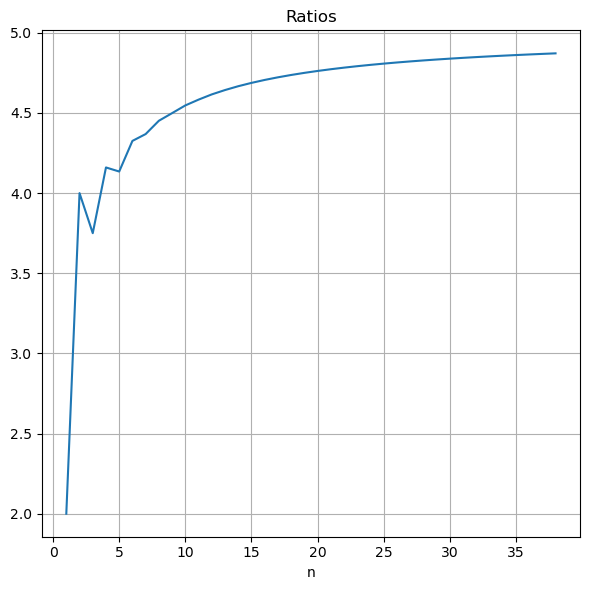

In [44]:
plt.figure(figsize=(6, 6))
plt.plot(arrange_count, quotient_count)
plt.xlabel('n')
plt.title('Ratios')
plt.grid(True)
plt.tight_layout()
plt.show()


# The ratio sequence $\frac{M_{n+1}(q)}{M_n(q)}$ for various values of $q$.

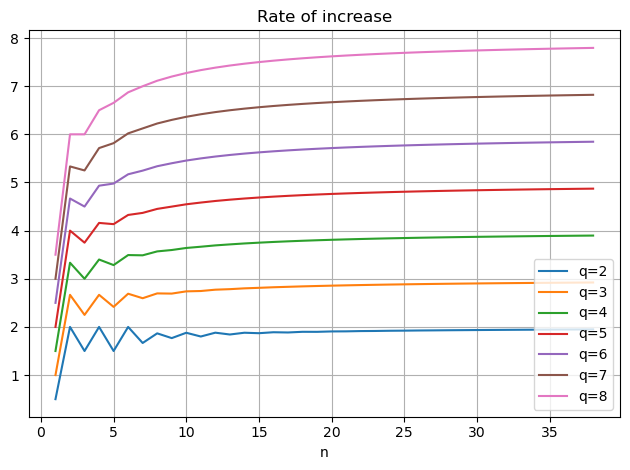

In [16]:
q_list = [2, 3, 4, 5, 6, 7,8]
m = 40
for q in q_list:
    count = [count_poly(q,n) for n in range(1,m)]
    count = np.array(count)
    quotient_count = (count[1:]/count[:-1]).astype(float)
    arrange_count = np.array(range(1,m-1))
    plt.plot(arrange_count, quotient_count, label=f'q={q}')
plt.xlabel('n')
plt.title('Rate of increase')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('ratio_sequences_small_q_new.pdf', format='pdf', dpi=200)
plt.show()

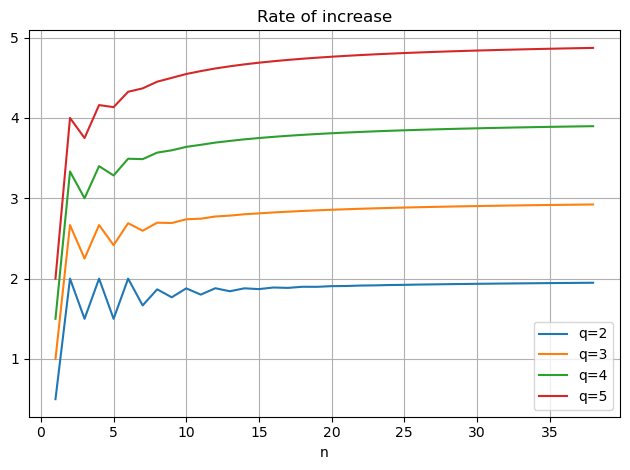

In [11]:
q_list = [2, 3, 4, 5]
m = 40
for q in q_list:
    count = [count_poly(q,n) for n in range(1,m)]
    count = np.array(count)
    quotient_count = (count[1:]/count[:-1]).astype(float)
    arrange_count = np.array(range(1,m-1))
    plt.plot(arrange_count, quotient_count, label=f'q={q:n}')
plt.xlabel('n')
plt.title('Rate of increase')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('ratio_sequences_small_q.pdf', format='pdf', bbox_inches='tight', dpi=200)
plt.show()

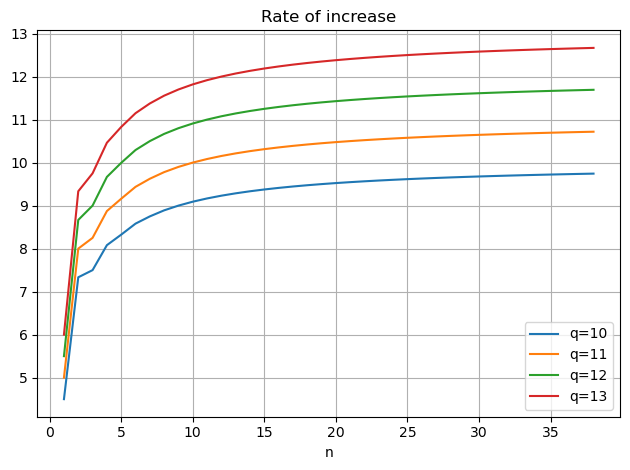

In [51]:
q_list = [10, 11, 12, 13]
m = 40
for q in q_list:
    count = [count_poly(q,n) for n in range(1,m)]
    count = np.array(count)
    quotient_count = (count[1:]/count[:-1]).astype(float)
    arrange_count = np.array(range(1,m-1))
    plt.plot(arrange_count, quotient_count, label=f'q={q}')
plt.xlabel('n')
plt.title('Rate of increase')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('ratio_sequences_big_q.pdf', format='pdf', bbox_inches='tight', dpi=200)
plt.show()

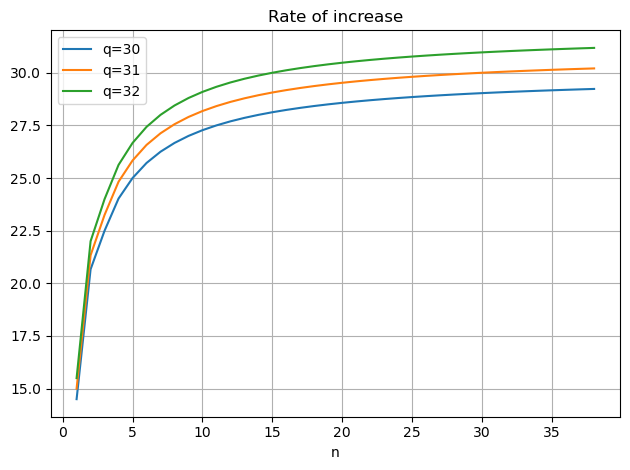

In [53]:
q_list = [30, 31, 32]
m = 40
for q in q_list:
    count = [count_poly(q,n) for n in range(1,m)]
    count = np.array(count)
    quotient_count = (count[1:]/count[:-1]).astype(float)
    arrange_count = np.array(range(1,m-1))
    plt.plot(arrange_count, quotient_count, label=f'q={q}')
plt.xlabel('n')
plt.title('Rate of increase')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('ratio_sequences_big_q.pdf', format='pdf', bbox_inches='tight', dpi=200)
plt.show()

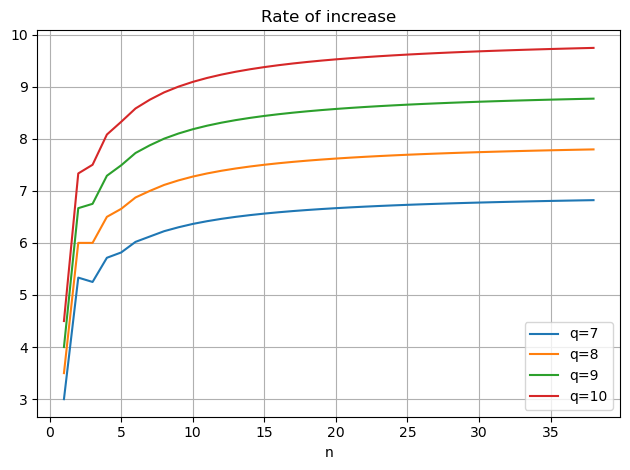

In [4]:
q_list = [7,8, 9, 10]
m = 40
for q in q_list:
    count = [count_poly(q,n) for n in range(1,m)]
    count = np.array(count)
    quotient_count = (count[1:]/count[:-1]).astype(float)
    arrange_count = np.array(range(1,m-1))
    plt.plot(arrange_count, quotient_count, label=f'q={q}')
plt.xlabel('n')
plt.title('Rate of increase')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('ratio_sequences_medium_q.pdf', format='pdf', bbox_inches='tight', dpi=200)
plt.show()

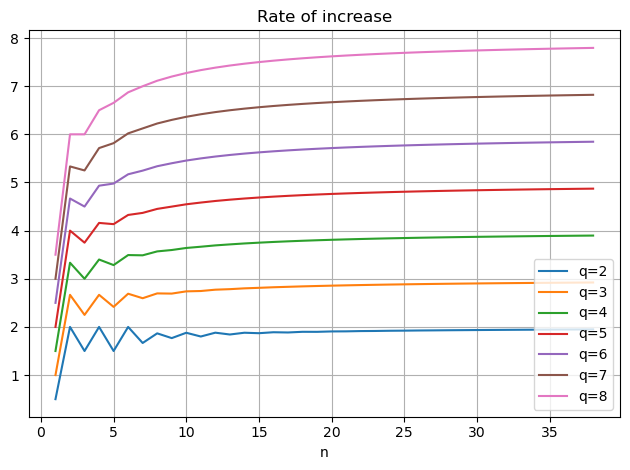

In [18]:
q_list = [2, 3, 4, 5, 6, 7,8]
m = 40
fig, ax = plt.subplots()
for q in q_list:
    count = [count_poly(q,n) for n in range(1,m)]
    count = np.array(count)
    quotient_count = (count[1:]/count[:-1]).astype(float)
    arrange_count = np.array(range(1,m-1))
    ax.plot(arrange_count, quotient_count, label=f'q={q}')
ax.set_xlabel('n')
ax.set_title('Rate of increase')
leg = ax.legend(loc='lower right')   # fix location
ax.grid(True)
fig.tight_layout()
fig.savefig('ratio_sequences_small_q_new.pdf', bbox_inches='tight', dpi=200)
plt.show()
